In [2]:
import pandas as pd
data = pd.DataFrame({
    "age":[22,38,26,35,28,40,19,30],
    "fare":[7.25,71.28,7.92,53.10,8.05,31.00,7.89,15.50],
    "sex":["male","female","female","female","male","male","male","female"],
    "pclass":[3,1,3,1,3,2,3,2],
    "survived":[0,1,1,1,0,0,0,1]
})

In [3]:
data

,age,fare,sex,pclass,survived
0,22,7.25,male,3,0
1,38,71.28,female,1,1
2,26,7.92,female,3,1
3,35,53.10,female,1,1
4,28,8.05,male,3,0
5,40,31.00,male,2,0
6,19,7.89,male,3,0
7,30,15.50,female,2,1


In [4]:
from sklearn.model_selection import train_test_split
x=data.drop('survived',axis=1)
y=data['survived']

x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.2, random_state=42)


### scikit-learn은 범주형을 숫자로 변환해서 사용한다.

In [ ]:
pd.get_dummies(x_train,columns=['sex','pclass'])

# 범주형 데이터를
# 0과 1로 바꿔주는 함수

# 이걸 원-핫 인코딩(One-Hot Encoding)이라고 합니다.

,age,fare,sex_female,sex_male,pclass_1,pclass_2,pclass_3
0,22,7.25,False,True,False,False,True
7,30,15.50,True,False,False,True,False
2,26,7.92,True,False,False,False,True
4,28,8.05,False,True,False,False,True
3,35,53.10,True,False,True,False,False
6,19,7.89,False,True,False,False,True


In [7]:
#훈련/테스트 데이터를 각각 더미변수화
x_train_encoded=pd.get_dummies(x_train,columns=['sex','pclass'])
x_test_encoded=pd.get_dummies(x_test,columns=['sex','pclass'])

In [8]:
x_train_encoded

,age,fare,sex_female,sex_male,pclass_1,pclass_2,pclass_3
0,22,7.25,False,True,False,False,True
7,30,15.50,True,False,False,True,False
2,26,7.92,True,False,False,False,True
4,28,8.05,False,True,False,False,True
3,35,53.10,True,False,True,False,False
6,19,7.89,False,True,False,False,True


In [9]:
x_test_encoded

,age,fare,sex_female,sex_male,pclass_1,pclass_2
1,38,71.28,True,False,True,False
5,40,31.00,False,True,False,True


In [10]:
#혹시train/test컬럼이 다르면 맞춰주기
x_train_encoded,x_test_encoded=x_train_encoded.align(x_test_encoded,join='left',axis=1, fill_value=0)

In [11]:
x_test_encoded

,age,fare,sex_female,sex_male,pclass_1,pclass_2,pclass_3
1,38,71.28,True,False,True,False,0
5,40,31.00,False,True,False,True,0


In [16]:
from sklearn.tree import DecisionTreeClassifier

sk_model = DecisionTreeClassifier(random_state=42)
sk_model.fit(x_train_encoded, y_train)

sk_pred=sk_model.predict(x_test_encoded)

print('==scikit-learn===')
print('변환후훈련칼럼')
print(x_train_encoded.columns.tolist())

print('예측값',sk_pred)
print('정답',y_test.values)
print('정확도',sk_model.score(x_test_encoded,y_test))


==scikit-learn===
변환후훈련칼럼
['age', 'fare', 'sex_female', 'sex_male', 'pclass_1', 'pclass_2', 'pclass_3']
예측값 [1 0]
정답 [1 0]
정확도 1.0


In [18]:
#%pip install catboost

In [ ]:
from catboost import CatBoostClassifier

#범주형 변수 알려주기
cat_features=['sex','pclass']

cat_model=CatBoostClassifier(
    iterations=100, #트리개수
    depth=4, #트리깊이
    learning_rate=0.1,
    verbose=5,#학습과정 출력할지의 여부, 0아무것도 출력하지 않음, 숫자를 주면 몇번마다 출력할지 결정
    random_state=42
    )

cat_model.fit(x_train, y_train, cat_features=cat_features)

0:	learn: 0.6858650	total: 10.5ms	remaining: 1.04s
5:	learn: 0.6115918	total: 54ms	remaining: 847ms
10:	learn: 0.5573757	total: 103ms	remaining: 830ms
15:	learn: 0.5027561	total: 144ms	remaining: 756ms
20:	learn: 0.4469243	total: 175ms	remaining: 658ms
25:	learn: 0.4056368	total: 208ms	remaining: 593ms
30:	learn: 0.3682912	total: 242ms	remaining: 539ms
35:	learn: 0.3362763	total: 282ms	remaining: 501ms
40:	learn: 0.3100820	total: 317ms	remaining: 456ms
45:	learn: 0.2860544	total: 350ms	remaining: 411ms
50:	learn: 0.2626682	total: 380ms	remaining: 366ms
55:	learn: 0.2414131	total: 408ms	remaining: 321ms
60:	learn: 0.2228945	total: 434ms	remaining: 277ms
65:	learn: 0.2066628	total: 460ms	remaining: 237ms
70:	learn: 0.1923549	total: 488ms	remaining: 199ms
75:	learn: 0.1796752	total: 516ms	remaining: 163ms
80:	learn: 0.1683822	total: 545ms	remaining: 128ms
85:	learn: 0.1582769	total: 575ms	remaining: 93.6ms
90:	learn: 0.1491943	total: 601ms	remaining: 59.4ms
95:	learn: 0.1409971	total: 626

CatBoostClassifier(depth=4, iterations=100, learning_rate=0.1, random_state=42, verbose=5)

In [23]:
cat_pred=cat_model.predict(x_test)
print(cat_pred)

[1 0]


In [24]:
y_test.values

array([1, 0])

In [26]:
print('===catboost===')
print('예측값', cat_pred.ravel())
print('정답',y_test.values)
print('정확도',cat_model.score(x_test,y_test))

===catboost===
예측값 [1 0]
정답 [1 0]
정확도 1.0


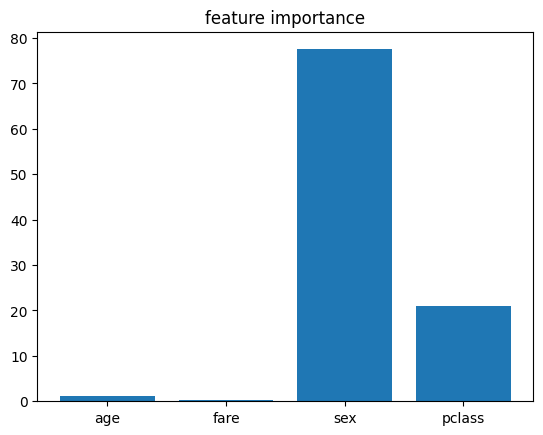

In [27]:
import matplotlib.pyplot as plt

importance=cat_model.get_feature_importance()

plt.bar(x.columns, importance)
plt.title("feature importance")
plt.show()